# Notebook 2 - Feature Engineering

Neste notebook, analisaremos a base tratada de clientes e identificaremos possíveis oportunidades para criação de features para serem usadas no processo de modelagem

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

In [2]:
pasta_notebooks = Path.cwd() if Path.cwd().name == 'notebooks' else Path.cwd() / 'notebooks'
caminho_base_tratada = pasta_notebooks / 'dados' / '1-base_clientes_tratada.pkl'
base_tratada = pd.read_pickle(caminho_base_tratada)

print(f'Dimensoes: {base_tratada.shape[0]} linhas x {base_tratada.shape[1]} colunas')

Dimensoes: 758 linhas x 22 colunas


Primeiro, leremos a base de interacoes para a criação de features derivadas. Cruzaremos ela com a base de clientes tratada através das chaves id_cliente e data_referencia, tendo cautela para que todas as variáveis sejam calculadas até a data de referência.

In [3]:
# Carga das interacoes e padronizacao das chaves/datas
caminho_interacoes = pasta_notebooks.parent / 'interacoes.csv'
interacoes = pd.read_csv(caminho_interacoes, encoding='utf-8')

clientes = base_tratada.copy()
clientes['data_referencia'] = pd.to_datetime(clientes['data_referencia'])
interacoes['data_interacao'] = pd.to_datetime(interacoes['data_interacao'])

# Mantem apenas informacao disponivel no momento de cada referencia (sem leakage temporal).
historico = interacoes.merge(
    clientes[['id_cliente', 'data_referencia']],
    on='id_cliente',
    how='inner'
)
historico = historico[historico['data_interacao'] <= historico['data_referencia']].copy()

Com a base 'histórico' definida para a construção das variáveis, iremos criar 8 features distintas o suficiente de si. De início, avaliaremos a cobertura destas variáveis.

In [4]:

# Agregacoes construidas uma a uma no nivel cliente.
qtd_interacoes = historico.groupby('id_cliente').size().rename('qtd_interacoes_ate_ref')
ultima_interacao = historico.groupby('id_cliente')['data_interacao'].max()

def taxa_resultado(resultado):
    return historico.assign(_indicador=historico['resultado'].eq(resultado)).groupby('id_cliente')['_indicador'].mean()

sucesso = taxa_resultado('intencao_pagamento')
receptividade = historico.assign(_indicador=historico['direcao'].eq('receptiva')).groupby('id_cliente')['_indicador'].mean()
canais = historico.groupby('id_cliente')['canal'].nunique().rename('qtd_canais_distintos_ate_ref')
promessa = historico.assign(_indicador=historico['resultado'].eq('promessa_registrada')).groupby('id_cliente')['_indicador'].max()
dificuldade = historico.assign(_indicador=historico['resultado'].eq('dificuldade_temporaria')).groupby('id_cliente')['_indicador'].max()
recusa = historico.assign(_indicador=historico['resultado'].eq('recusa_oferta')).groupby('id_cliente')['_indicador'].max()

features = clientes[['id_cliente', 'data_referencia']].copy()
features['qtd_interacoes_ate_ref'] = features['id_cliente'].map(qtd_interacoes).fillna(0).astype('int64')
features['dias_desde_ultima_interacao'] = (
    features['data_referencia'] - features['id_cliente'].map(ultima_interacao)
).dt.days.fillna(999).astype('int64')
features['taxa_intencao_pagamento'] = features['id_cliente'].map(sucesso).fillna(0)
features['taxa_receptividade_interacoes'] = features['id_cliente'].map(receptividade).fillna(0)
features['qtd_canais_distintos_ate_ref'] = features['id_cliente'].map(canais).fillna(0).astype('int64')
features['flag_promessa_interacao'] = features['id_cliente'].map(promessa).fillna(False).astype('int8')
features['flag_dificuldade_temporaria'] = features['id_cliente'].map(dificuldade).fillna(False).astype('int8')
features['flag_recusa_oferta'] = features['id_cliente'].map(recusa).fillna(False).astype('int8')

# Cruzamento final: preserva todos os clientes mesmo sem historico de interacoes.
base_com_features = base_tratada.merge(
    features.drop(columns='data_referencia'), on='id_cliente', how='left', validate='one_to_one'
)
base_com_features['safra'] = pd.to_datetime(base_com_features['data_referencia']).dt.to_period('M').astype(str)

# Definicoes para rastreabilidade das variaveis criadas.
definicoes_features = pd.DataFrame({
    'variavel': [
        'qtd_interacoes_ate_ref', 'dias_desde_ultima_interacao',
        'taxa_intencao_pagamento', 'taxa_receptividade_interacoes',
        'qtd_canais_distintos_ate_ref', 'flag_promessa_interacao',
        'flag_dificuldade_temporaria', 'flag_recusa_oferta'
    ],
    'definicao': [
        'Quantidade de interacoes do cliente ate a data de referencia.',
        'Dias desde a ultima interacao elegivel; 999 representa ausencia de historico.',
        'Proporcao de interacoes com resultado intencao_pagamento.',
        'Proporcao de interacoes receptivas no historico elegivel.',
        'Quantidade de canais distintos usados ate a referencia.',
        'Indica se houve promessa registrada antes ou na referencia.',
        'Indica se apareceu dificuldade temporaria no historico.',
        'Indica se houve recusa de oferta no historico.'
    ]
})
print('Variaveis criadas e definicoes:')
display(definicoes_features)
print(f'Base enriquecida: {base_com_features.shape[0]} linhas x {base_com_features.shape[1]} colunas')

variaveis_features = definicoes_features['variavel'].tolist()

# Cobertura por safra e alertas simples para apoiar a revisao de anomalias.
cobertura_safra = base_com_features.groupby('safra')[variaveis_features].apply(lambda bloco: ((bloco != 0)&(bloco.notnull())).mean()).round(3)
print('Cobertura/proporcao positiva por safra:')
display(cobertura_safra)


Variaveis criadas e definicoes:


,variavel,definicao
0,qtd_interacoes_ate_ref,Quantidade de interacoes do cliente ate a data...
1,dias_desde_ultima_interacao,Dias desde a ultima interacao elegivel; 999 re...
2,taxa_intencao_pagamento,Proporcao de interacoes com resultado intencao...
3,taxa_receptividade_interacoes,Proporcao de interacoes receptivas no historic...
4,qtd_canais_distintos_ate_ref,Quantidade de canais distintos usados ate a re...
5,flag_promessa_interacao,Indica se houve promessa registrada antes ou n...
6,flag_dificuldade_temporaria,Indica se apareceu dificuldade temporaria no h...
7,flag_recusa_oferta,Indica se houve recusa de oferta no historico.


Base enriquecida: 758 linhas x 30 colunas
Cobertura/proporcao positiva por safra:


,qtd_interacoes_ate_ref,dias_desde_ultima_interacao,taxa_intencao_pagamento,taxa_receptividade_interacoes,qtd_canais_distintos_ate_ref,flag_promessa_interacao,flag_dificuldade_temporaria,flag_recusa_oferta
safra,,,,,,,,
2026-01,1.0,1.0,0.547,0.479,1.0,0.342,0.462,0.265
2026-02,1.0,1.0,0.516,0.460,1.0,0.435,0.363,0.258
2026-03,1.0,1.0,0.415,0.528,1.0,0.338,0.465,0.324
2026-04,1.0,1.0,0.500,0.515,1.0,0.336,0.358,0.246
2026-05,1.0,1.0,0.500,0.518,1.0,0.382,0.382,0.209
2026-06,1.0,1.0,0.458,0.450,1.0,0.359,0.504,0.191


Destas variáveis, apenas qtd_interacoes_ate_ref, dias_desde_ultima_interacao e qtd_canais_distintos_ate_ref possuem cobertura completa. Focaremos nestas para as análises posteriores, começando pela estabilidade por safra.    

In [5]:

variaveis_features = ['qtd_interacoes_ate_ref', 'dias_desde_ultima_interacao', 'qtd_canais_distintos_ate_ref']

resumo_estabilidade = base_com_features.groupby('safra')[variaveis_features].agg(['mean', 'std', 'min', 'max']).round(3)
print('Estabilidade por safra (media, desvio, minimo e maximo):')
display(resumo_estabilidade)

Estabilidade por safra (media, desvio, minimo e maximo):


qtd_interacoes_ate_ref                dias_desde_ultima_interacao  \
                          mean    std min max                        mean   
safra                                                                       
2026-01                  3.009  1.477   1   5                      23.051   
2026-02                  3.008  1.440   1   5                      22.677   
2026-03                  3.049  1.411   1   5                      22.324   
2026-04                  2.978  1.474   1   5                      22.769   
2026-05                  2.864  1.371   1   5                      21.273   
2026-06                  2.947  1.469   1   5                      22.229   

                        qtd_canais_distintos_ate_ref                 
            std min max                         mean    std min max  
safra                                                                
2026-01  17.890   1  73                        2.051  0.918   1   4  
2026-02  18.286   1  75                        2.073  0.885   1   4  
2026-03  18.712   1  74                        2.134  0.877   1   4  
2026-04  20.281   1  75                        2.097  0.875   1   4  
2026-05  16.870   1  68                        2.036  0.867   1   4  
2026-06  19.440   1  74                        2.053  0.922   1   4

Também iremos analisar a estabilidade via variação percentual da média contra a safra anterior:

In [6]:
variacao_media = base_com_features.groupby('safra')[variaveis_features].mean().pct_change().replace([np.inf, -np.inf], np.nan).round(3)
print('Variacao percentual da media contra a safra anterior:')
display(variacao_media)

Variacao percentual da media contra a safra anterior:


,qtd_interacoes_ate_ref,dias_desde_ultima_interacao,qtd_canais_distintos_ate_ref
safra,,,
2026-01,NaN,NaN,NaN
2026-02,-0.000,-0.016,0.010
2026-03,0.014,-0.016,0.030
2026-04,-0.024,0.020,-0.017
2026-05,-0.038,-0.066,-0.029
2026-06,0.029,0.045,0.008


Por fim, visualizaremos as variáveis de acordo com seu comportamento safra a safra:

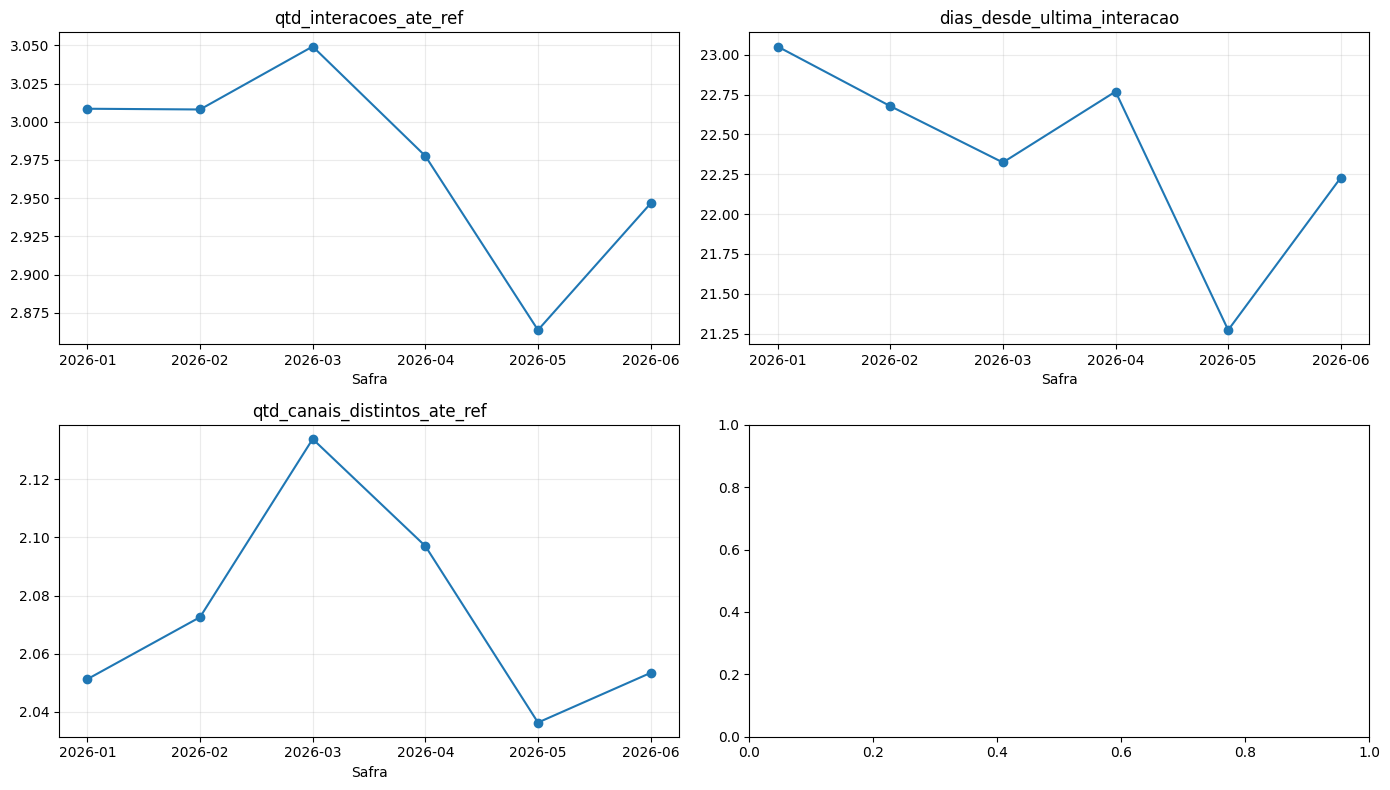

In [7]:
# Graficos compactos para inspeccao visual da estabilidade.
fig, eixos = plt.subplots(2, 2, figsize=(14, 8))
for eixo, variavel in zip(eixos.ravel(), variaveis_features[:4]):
    base_com_features.groupby('safra')[variavel].mean().plot(marker='o', ax=eixo, title=variavel)
    eixo.set_xlabel('Safra')
    eixo.grid(alpha=0.25)
plt.tight_layout()
plt.show()

In [8]:
# Dropando variáveis inutilizadas para o modelo final, com base na cobertura e estabilidade.
variaveis_dropadas = list(set(definicoes_features['variavel'].tolist())-set(variaveis_features))
base_com_features = base_com_features.drop(columns=variaveis_dropadas)

Nenhuma destas três variáveis apresenta problemas sérios de estabilidade. Portanto, seguiremos em frente com sua utilização. Abaixo, categorizaremos as variáveis pertinentes (que vêm preenchidas como strings) para utilização na modelagem.

In [9]:
# Identificacao e codificacao das variaveis categoricas para modelagem.
colunas_categoricas = ['setor', 'porte', 'canal_preferencial', 'risco_setorial']

base_com_features_categorizada = base_com_features.copy()
dicionario_categoricas = {}

for coluna in colunas_categoricas:
    valores_distintos = sorted(
        base_com_features[coluna].dropna().unique(),
        key=lambda valor: str(valor)
    )
    mapeamento = {
        valor: codigo for codigo, valor in enumerate(valores_distintos, start=1)
    }
    dicionario_categoricas[coluna+'_cat'] = mapeamento
    base_com_features_categorizada[coluna+'_cat'] = base_com_features[coluna].map(mapeamento)

print('Variaveis categoricas identificadas:')
print(colunas_categoricas)
print('\nDicionario de valores categoricos:')
for coluna, mapeamento in dicionario_categoricas.items():
    print(f'{coluna}: {mapeamento}')

print(
    f'Base categorizada: {base_com_features_categorizada.shape[0]} linhas x '
    f'{base_com_features_categorizada.shape[1]} colunas'
)


Variaveis categoricas identificadas:
['setor', 'porte', 'canal_preferencial', 'risco_setorial']

Dicionario de valores categoricos:
setor_cat: {'Agronegócio': 1, 'Comércio': 2, 'Construção': 3, 'Indústria': 4, 'Serviços': 5, 'Tecnologia': 6}
porte_cat: {'EPP': 1, 'Grande': 2, 'ME': 3, 'Média': 4}
canal_preferencial_cat: {'email': 1, 'nulo': 2, 'portal': 3, 'telefone': 4, 'whatsapp': 5}
risco_setorial_cat: {'alto': 1, 'baixo': 2, 'medio': 3}
Base categorizada: 758 linhas x 29 colunas


Para a região, utilizaremos uma segmentação específica dada a volumetria:

In [10]:
# Categorizacao especifica da UF para modelagem.
uf_prioritarias = ['SP', 'RJ', 'MG']
base_com_features_categorizada['regiao'] = np.select(
    [base_com_features['uf']=='SP', base_com_features['uf']=='RJ', base_com_features['uf']=='MG'],
    [1, 2, 3],
    default=4
)
print('\nDistribuicao da UF categorizada:')
print(base_com_features_categorizada['regiao'].value_counts().sort_index())



Distribuicao da UF categorizada:
1    313
2    101
3    101
4    243
Name: regiao, dtype: int64


In [11]:
# Persistencia da base final para uso na modelagem.
caminho_base_features = pasta_notebooks / 'dados' / '2-base_features.pkl'
base_com_features_categorizada.to_pickle(caminho_base_features)

print(f'Base salva em: {caminho_base_features}')
print(
    f'Dimensoes: {base_com_features_categorizada.shape[0]} linhas x '
    f'{base_com_features_categorizada.shape[1]} colunas'
)


Base salva em: c:\Users\Victor Dogo\Documents\ds3_mlai_test\notebooks\dados\2-base_features.pkl
Dimensoes: 758 linhas x 30 colunas
